We clustered adverbs and adjectives based on feature vectors, where each value in the vector was a proportion of the lemmas having the property on that column. 
The question is now if we did the same using word2vec embeddings - clustered all the lemmas based on their w2v embedding - would we get similar clusters?

In [2]:
from gensim.models import KeyedVectors

# Path to the downloaded model file
model_path = "/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/8.w2v_clustering/43/model.txt"  

# Load the Word2Vec model
word2vec_model = KeyedVectors.load_word2vec_format(model_path, binary=False, unicode_errors='ignore')

# Check the vocabulary size
print(f"Vocabulary size: {len(word2vec_model.key_to_index)}")

# Example: Get the embedding for a word
word = "chat"  # Replace with a French word
if word in word2vec_model:
    embedding = word2vec_model[word]
    print(f"Embedding for '{word}': {embedding}")
else:
    print(f"'{word}' not found in the vocabulary.")

Vocabulary size: 2567698
Embedding for 'chat': [-0.359658 -0.087234  0.374839  0.052932  0.289825  0.028792  0.113546
 -0.09405   0.122435  0.552035 -0.523718  0.562333  0.364452  0.08581
 -0.082521 -0.111139  0.198197 -0.416301  0.251889  0.528702 -0.321478
 -0.067916 -0.540747 -0.1354    0.046606 -0.247299  0.129657 -0.421766
 -0.347722  0.62845   0.328172  0.088378  0.062902 -0.302594  0.362315
  0.042298  0.56082  -0.213239  0.451069 -0.103975 -0.411043  0.529768
 -0.563731 -0.10243   0.544699  0.19145   0.297052 -0.261126  0.510212
  0.093054  0.173033 -0.126806  0.15496   0.101904  0.109748 -0.415577
 -0.058241 -0.013055 -0.019823 -0.247056 -0.005057  0.123928  0.628373
 -0.064102 -0.193984  0.085897 -0.083557 -0.297159  0.336527  0.395139
  0.112885  0.082165  0.079557 -0.413044 -0.186695 -0.332597 -0.093002
  0.50021  -0.381199 -0.316224  0.390407 -0.286235  0.105015 -0.115846
 -0.002772  0.159163 -0.31732  -0.170286  0.334615 -0.295619 -0.023874
 -0.072452  0.866855  0.067524 

In [3]:
from conllu import parse
treebanks_path = '/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master'
files_to_read = ['/fr_gsd-ud-train.conllu', '/fr_gsd-ud-dev.conllu', '/fr_gsd-ud-test.conllu']
data = ''
for file in files_to_read:
    with open(treebanks_path + file, 'r') as f:
        data += f.read()


parsed_data = parse(data)
print(parsed_data[0])

adv_lemmas = []
for sentence in parsed_data:
    for token in sentence:
        if token['upostag'] == 'ADV':
            adv_lemmas.append(token['lemma'])

# print(adv_lemmas)
# print(len(adv_lemmas))
# adv_lemmas = list(adv_lemmas)

TokenList<Les, commotions, cérébrales, sont, devenu, si, courantes, dans, ce, sport, qu', on, les, considére, presque, comme, la, routine, ., metadata={global.columns: "ID FORM LEMMA UPOS XPOS FEATS HEAD DEPREL DEPS MISC", sent_id: "fr-ud-train_00001", text: "Les commotions cérébrales sont devenu si courantes dans ce sport qu'on les considére presque comme la routine."}>


In [4]:
# remove the adverbs with less than 10 occurrences
print(len(adv_lemmas))
adv_lemmas = [item for item in adv_lemmas if adv_lemmas.count(item) > 10]
print(len(set(adv_lemmas)))
adv_lemmas = list(set(adv_lemmas))

14142
127


In [5]:

# Function to generate w2v embeddings for a list of lemmas
def get_w2v_embeddings(lemmas):
    embeddings = []
    for lemma in lemmas:
        if lemma in word2vec_model:
            embeddings.append(word2vec_model[lemma])
        else:
            print(f"'{lemma}' not found in the vocabulary")
    return embeddings
# Generate embeddings for the adverb lemmas
adverb_embeddings = get_w2v_embeddings(adv_lemmas)

# Display the shape of the embeddings to verify
print(f"Generated {len(adverb_embeddings)} embeddings with shape {adverb_embeddings[0].shape}")

Generated 127 embeddings with shape (100,)


In [6]:
import numpy as np
# turn list into numpy array
adverb_embeddings = np.array(adverb_embeddings)
print(adverb_embeddings.shape)
print(type(adv_lemmas))

(127, 100)
<class 'list'>


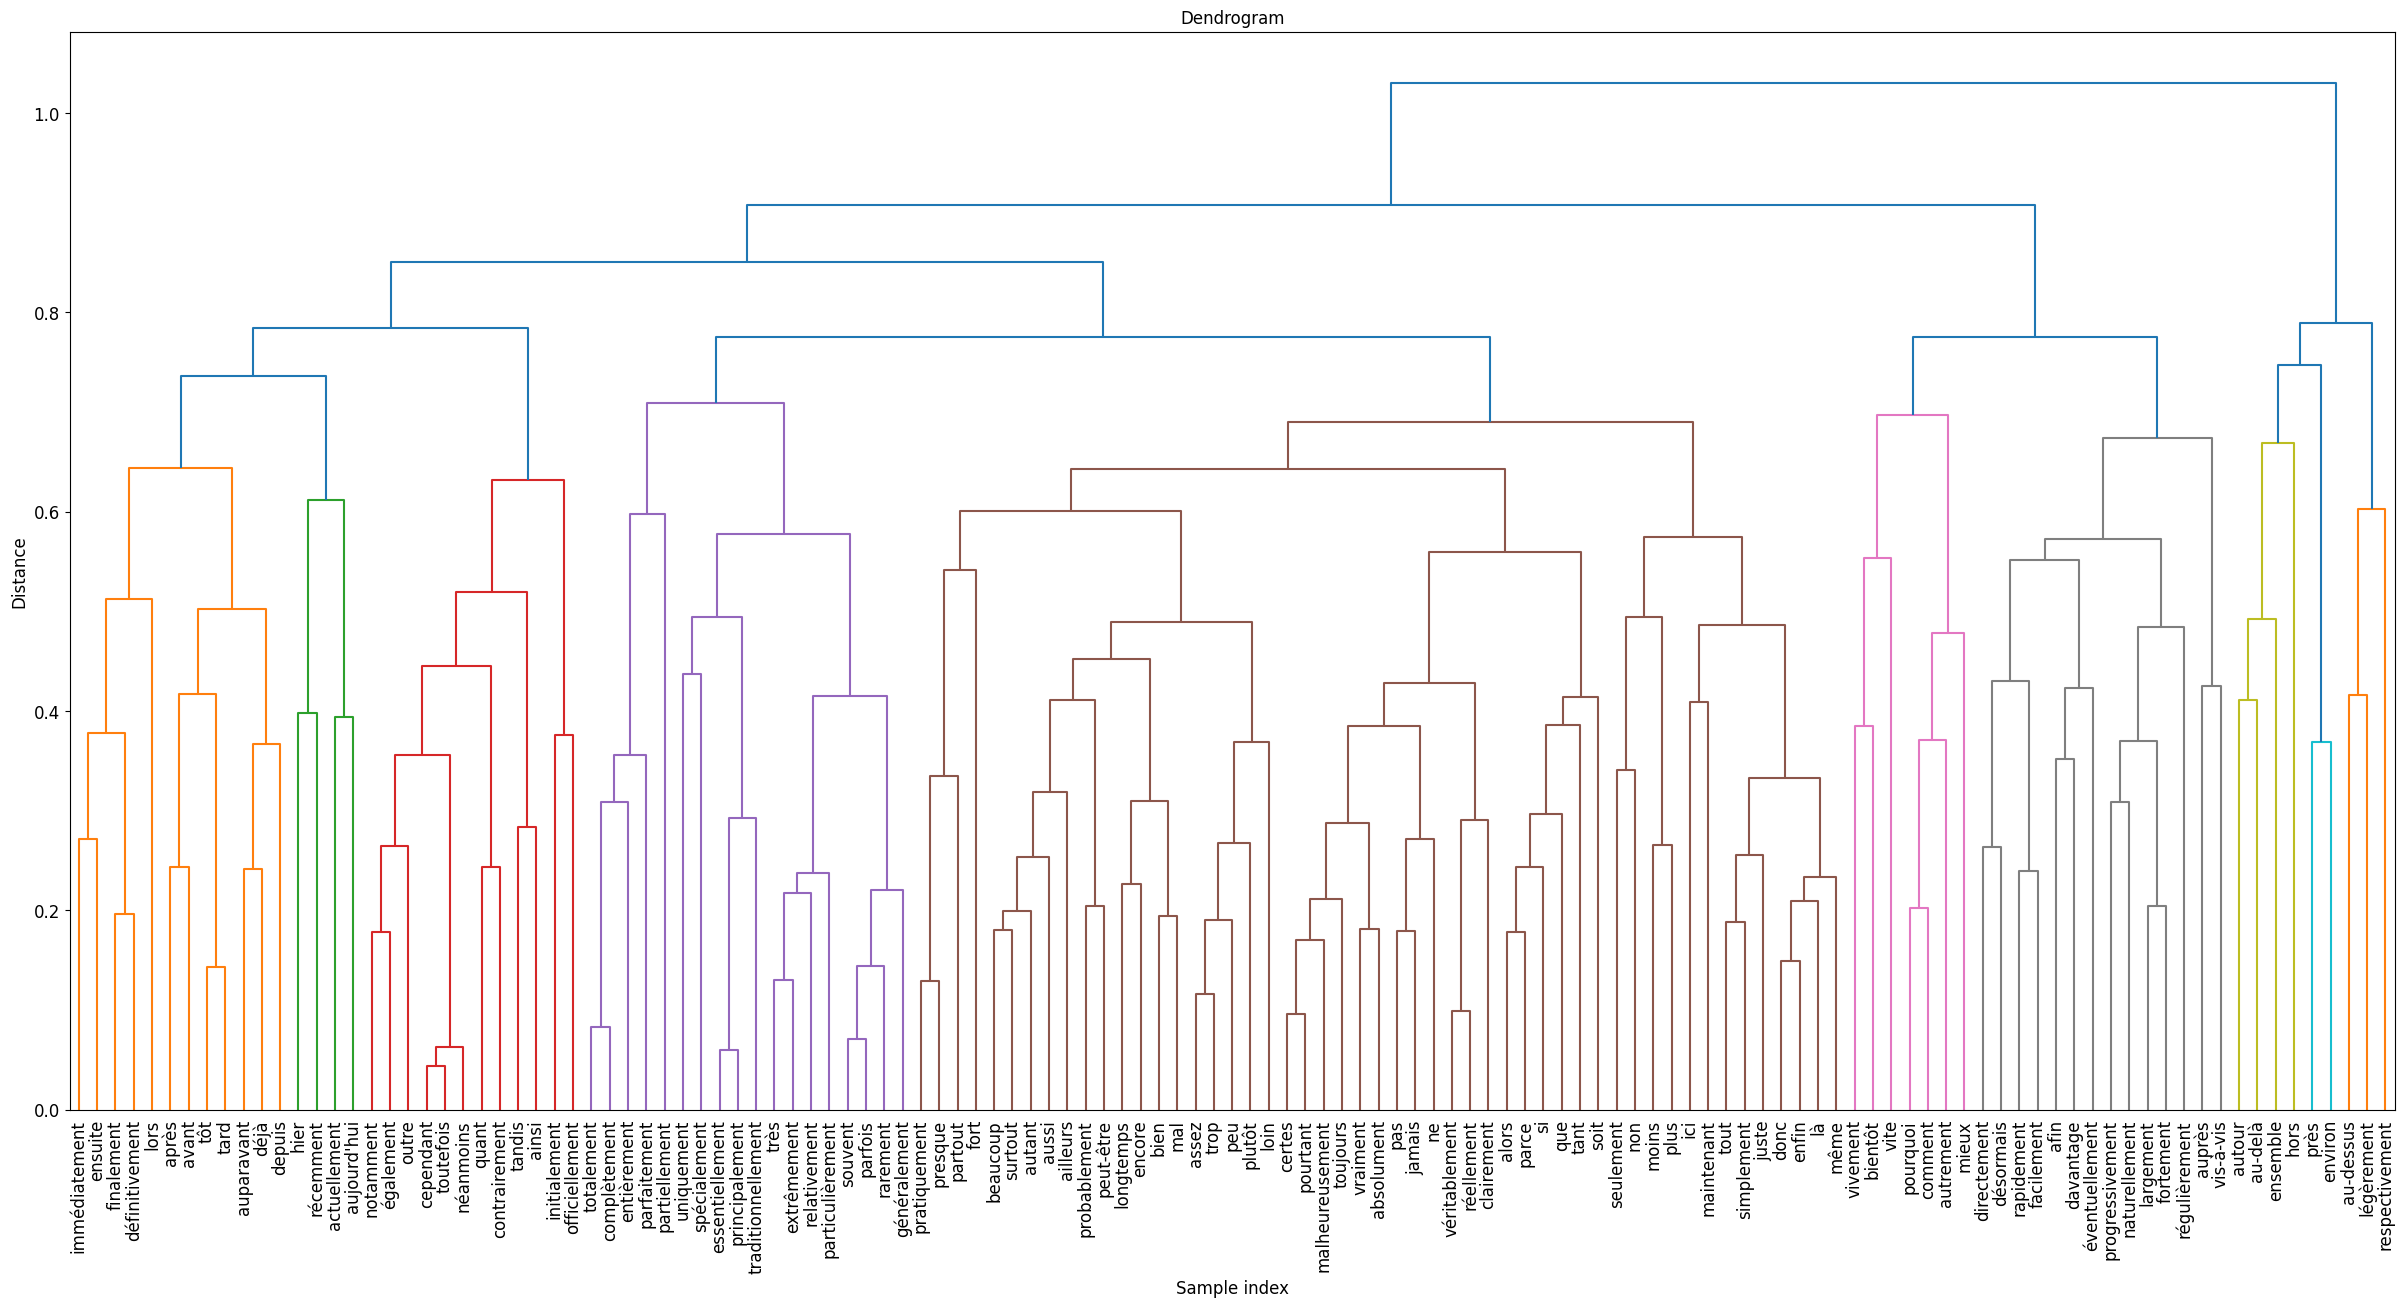

In [7]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, to_tree
import matplotlib.pyplot as plt

distance_matrix = pdist(adverb_embeddings, metric='cosine')
# Complete -> we cluster 
linked = linkage(distance_matrix, method="complete", optimal_ordering=True)

plt.figure(figsize=(30, 14))

dn = dendrogram(linked,
                orientation='top',
                labels=[name for name in adv_lemmas],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Dendrogram', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

In [8]:
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score

def find_optimal_clusters(X, max_clusters=20, metric='cosine', method='complete'):
    distance_matrix = pdist(X, metric=metric)
    linked = linkage(distance_matrix, method=method, optimal_ordering=True)
    
    silhouette_scores = []
    for num_clusters in range(2, max_clusters + 1):
        labels = fcluster(linked, num_clusters, criterion='maxclust')
        if len(np.unique(labels)) > 1:  # Ensure there is more than one cluster
            score = silhouette_score(X, labels, metric=metric)
            silhouette_scores.append(score)
            print(f'Number of clusters: {num_clusters}, Silhouette Score: {score}')
        else:
            silhouette_scores.append(-1)  # Append a low score if only one cluster
    
    optimal_clusters = np.argmax(silhouette_scores) + 2  # +2 because range starts from 2
    return optimal_clusters, silhouette_scores
optimal_clusters, silhouette_scores = find_optimal_clusters(adverb_embeddings, max_clusters=126)
print(f'Optimal number of clusters: {optimal_clusters}')
print(adverb_embeddings.shape)

Number of clusters: 2, Silhouette Score: 0.2218426764011383
Number of clusters: 3, Silhouette Score: 0.09708628803491592
Number of clusters: 4, Silhouette Score: 0.10919761657714844
Number of clusters: 5, Silhouette Score: 0.10776234418153763
Number of clusters: 6, Silhouette Score: 0.09809773415327072
Number of clusters: 7, Silhouette Score: 0.09355854243040085
Number of clusters: 8, Silhouette Score: 0.1017836406826973
Number of clusters: 9, Silhouette Score: 0.10563308000564575
Number of clusters: 10, Silhouette Score: 0.10989443957805634
Number of clusters: 11, Silhouette Score: 0.11872903257608414
Number of clusters: 12, Silhouette Score: 0.11737921088933945
Number of clusters: 13, Silhouette Score: 0.09612638503313065
Number of clusters: 14, Silhouette Score: 0.09930980205535889
Number of clusters: 15, Silhouette Score: 0.09936688840389252
Number of clusters: 16, Silhouette Score: 0.09642808139324188
Number of clusters: 17, Silhouette Score: 0.07965146005153656
Number of clusters

In [9]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(adverb_embeddings)

In [10]:
# see what there is in each cluster
distance_matrix = pdist(adverb_embeddings, metric='cosine')
# Complete -> we cluster 
linked = linkage(distance_matrix, method="complete", optimal_ordering=True)
labels = fcluster(linked, optimal_clusters, criterion='maxclust')
clusters = {i: [] for i in range(1, optimal_clusters + 1)}
for i, label in enumerate(labels):
    clusters[label].append(i)

In [11]:
for cluster, members in clusters.items():
    print(f'Cluster {cluster}:')
    for member in members:
        print(f'  {adv_lemmas[member]}')

Cluster 1:
  respectivement
  au-dessus
  légèrement
  au-delà
  ensemble
  hors
  autour
  près
  environ
Cluster 2:
  pas
  facilement
  partout
  actuellement
  désormais
  surtout
  toujours
  souvent
  tandis
  jamais
  donc
  rapidement
  vis-à-vis
  essentiellement
  comment
  récemment
  trop
  après
  auparavant
  fort
  mieux
  traditionnellement
  encore
  certes
  extrêmement
  enfin
  ainsi
  malheureusement
  lors
  longtemps
  ensuite
  probablement
  quant
  maintenant
  contrairement
  ici
  vraiment
  officiellement
  moins
  beaucoup
  bien
  particulièrement
  régulièrement
  que
  généralement
  ne
  véritablement
  toutefois
  seulement
  progressivement
  aussi
  également
  presque
  là
  outre
  rarement
  mal
  simplement
  tôt
  tout
  parfaitement
  néanmoins
  largement
  complètement
  avant
  entièrement
  directement
  peut-être
  tard
  bientôt
  hier
  peu
  éventuellement
  principalement
  réellement
  ailleurs
  initialement
  assez
  non
  si
  spé

In [12]:
import plotly.graph_objects as go
import pandas as pd

# Create a DataFrame for Plotly
df = pd.DataFrame({
    'PCA1': X_tsne[:, 0],
    'PCA2': X_tsne[:, 1],
    'Cluster': labels,
    'Word': adv_lemmas
})
# pca1_min, pca1_max = df['PCA1'].min(), df['PCA1'].max()
# pca2_min, pca2_max = df['PCA2'].min(), df['PCA2'].max()
# Create a scatter plot with Plotly
fig = go.Figure()

# Add traces for each cluster
for cluster in range(1, optimal_clusters + 1):
    cluster_data = df[df['Cluster'] == cluster]
    fig.add_trace(go.Scatter(
        x=cluster_data['PCA1'],
        y=cluster_data['PCA2'],
        mode='markers',
        marker=dict(size=10),
        name=f'Cluster {cluster}',
        text=cluster_data['Word'],
        hovertemplate='%{text}<extra></extra>',
    ))

# Update layout with dropdown menu
fig.update_layout(
    title='Word Clusters',
    xaxis_title='tsne1',
    yaxis_title='tsne2',
    width=1600,  # Set the width of the figure
    height=800,  # Set the height of the figure
    # xaxis=dict(range=[pca1_min, pca1_max]),
    # yaxis=dict(range=[pca2_min, pca2_max]),
    updatemenus=[
        {
            'buttons': [
                {
                    'label': 'All Clusters',
                    'method': 'update',
                    'args': [{'visible': [True] * optimal_clusters},
                             {'title': 'All Clusters'}]
                }
            ] + [
                {
                    'label': f'Cluster {i}',
                    'method': 'update',
                    'args': [{'visible': [j == i - 1 for j in range(optimal_clusters)]},
                             {'title': f'Cluster {i}'}]
                } for i in range(1, optimal_clusters + 1)
            ],
            'direction': 'down',
            'showactive': True
        }
    ]
)

fig.show()

In [13]:
fig.write_html("/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/data/output/visualisations/w2v_adverbs_french_tsne.html")